In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print(df.shape)

(150, 5)


In [6]:
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
df_binary = df[df['species'].isin(['setosa', 'versicolor'])].copy()
df_binary['species'] = df_binary['species'].map({'setosa': 0, 'versicolor': 1})

In [9]:
print("\nBinary Target Distribution:\n", df_binary['species'].value_counts())


Binary Target Distribution:
 species
0    50
1    50
Name: count, dtype: int64


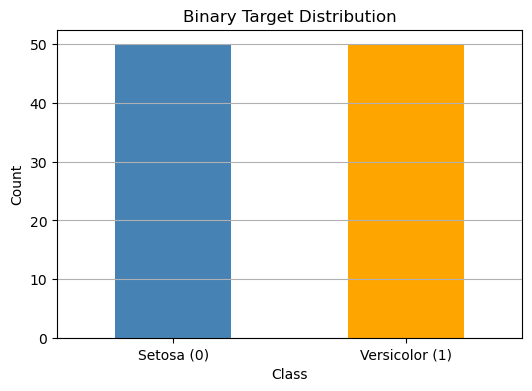

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df_binary['species'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Binary Target Distribution')
plt.xticks([0, 1], ['Setosa (0)', 'Versicolor (1)'], rotation=0)
plt.grid(axis='y')
plt.show()

In [25]:
X = df_binary.drop(columns=['species'])
y = df_binary['species']

In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [27]:
# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

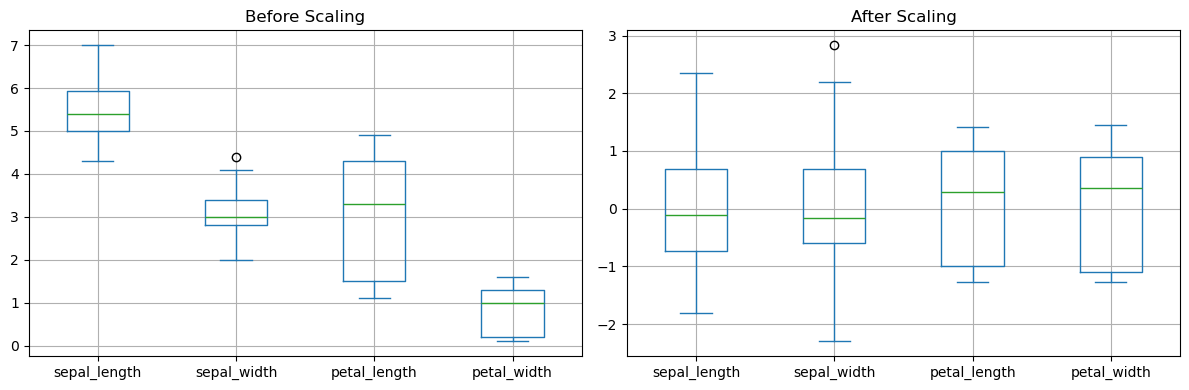

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_train.plot(kind='box', ax=axes[0])
axes[0].set_title('Before Scaling')
axes[0].grid(True)

pd.DataFrame(X_train_scaled, columns=X_train.columns).plot(kind='box', ax=axes[1])
axes[1].set_title('After Scaling')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Logistic Regression From Scratch

In [34]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = - (1/m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        m, n = X.shape
        
        self.weights = np.zeros(n)
        self.bias = 0

        self.losses = []

        for i in range(self.iterations):
            z = np.dot(X, self.weights) + self.bias   
            y_pred = self._sigmoid(z)

            loss = self._compute_loss(y, y_pred)
            self.losses.append(loss)

            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def get_probabilities(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        y_pred_bool = probabilities >= threshold
        return y_pred_bool.astype(int)

In [41]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train.values)

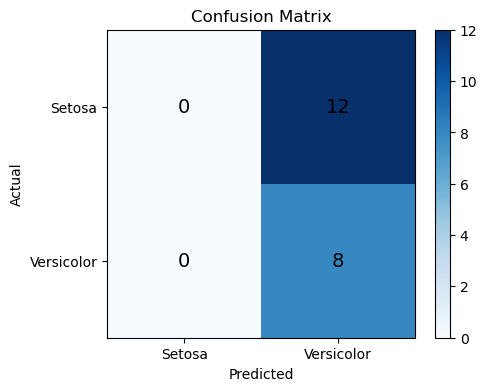

In [43]:
y_pred = model.predict(X_test)

cm = np.zeros((2, 2), dtype=int)
for actual, predicted in zip(y_test, y_pred):
    cm[actual][predicted] += 1

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['Setosa', 'Versicolor'])
plt.yticks([0, 1], ['Setosa', 'Versicolor'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center', fontsize=14, color='black')
plt.show()

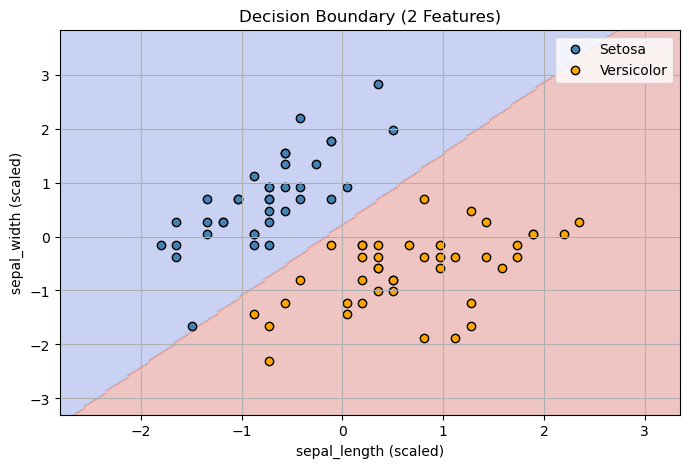

In [44]:
# Use only first 2 features for visualization
X2 = X_train_scaled[:, :2]
model2 = LogisticRegression()
model2.fit(X2, y_train.values)

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X2[y_train.values == 0, 0], X2[y_train.values == 0, 1],
            label='Setosa', color='steelblue', edgecolors='k')
plt.scatter(X2[y_train.values == 1, 0], X2[y_train.values == 1, 1],
            label='Versicolor', color='orange', edgecolors='k')
plt.xlabel('sepal_length (scaled)')
plt.ylabel('sepal_width (scaled)')
plt.title('Decision Boundary (2 Features)')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
import time

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -(1/len(y)) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def compute_accuracy(X, y, w, b):
    y_pred = (sigmoid(X @ w + b) >= 0.5).astype(int)
    return np.mean(y_pred == y)


In [46]:
X_tr = X_train_scaled
y_tr = y_train.values
X_te = X_test_scaled
y_te = y_test.values

In [47]:
# Full Batch GD 
w = np.zeros(X_tr.shape[1])
b = 0.0
gd_losses = []

start = time.time()
for _ in range(1000):
    y_pred = sigmoid(X_tr @ w + b)
    gd_losses.append(compute_loss(y_tr, y_pred))
    dw = (X_tr.T @ (y_pred - y_tr)) / len(y_tr)
    db = np.mean(y_pred - y_tr)
    w -= 0.1 * dw
    b -= 0.1 * db
gd_time = time.time() - start
gd_acc = compute_accuracy(X_te, y_te, w, b)

print("Full GD Results:")
print(f"  Training Time : {gd_time:.4f} seconds")
print(f"  Final Loss    : {gd_losses[-1]:.4f}")
print(f"  Accuracy      : {gd_acc:.4f}")

Full GD Results:
  Training Time : 0.0250 seconds
  Final Loss    : 0.0060
  Accuracy      : 1.0000


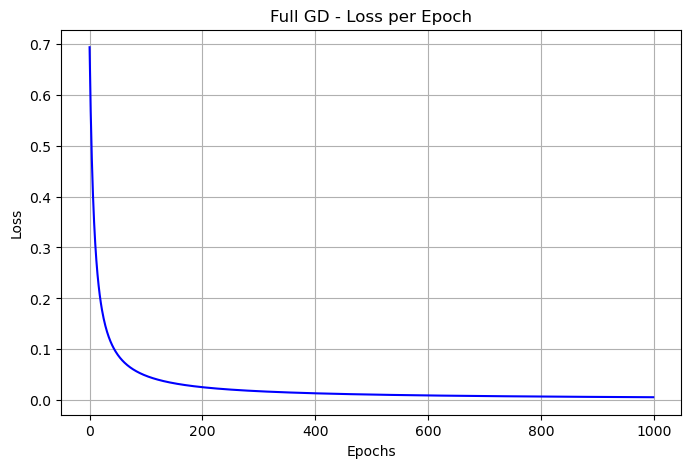

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(gd_losses, color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Full GD - Loss per Epoch')
plt.grid(True)
plt.show()

In [49]:
# SGD 
w = np.zeros(X_tr.shape[1])
b = 0.0
sgd_losses = []

start = time.time()
for _ in range(1000):
    idx = np.random.permutation(len(X_tr))
    for i in idx:
        xi = X_tr[i:i+1]
        yi = y_tr[i:i+1]
        y_pred = sigmoid(xi @ w + b)
        dw = xi.T @ (y_pred - yi)
        db = np.mean(y_pred - yi)
        w -= 0.1 * dw
        b -= 0.1 * db
    full_pred = sigmoid(X_tr @ w + b)
    sgd_losses.append(compute_loss(y_tr, full_pred))
sgd_time = time.time() - start
sgd_acc = compute_accuracy(X_te, y_te, w, b)

print("SGD Results:")
print(f"  Training Time : {sgd_time:.4f} seconds")
print(f"  Final Loss    : {sgd_losses[-1]:.4f}")
print(f"  Accuracy      : {sgd_acc:.4f}")

SGD Results:
  Training Time : 0.6430 seconds
  Final Loss    : 0.0001
  Accuracy      : 1.0000


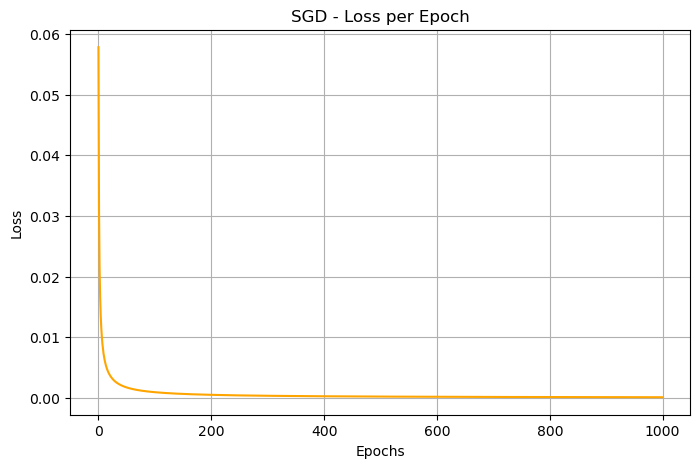

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(sgd_losses, color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('SGD - Loss per Epoch')
plt.grid(True)
plt.show()

In [51]:
# Mini-Batch GD (batch=16) 
w = np.zeros(X_tr.shape[1])
b = 0.0
mb16_losses = []

start = time.time()
for _ in range(1000):
    idx = np.random.permutation(len(X_tr))
    X_s, y_s = X_tr[idx], y_tr[idx]
    for i in range(0, len(X_tr), 16):
        xi, yi = X_s[i:i+16], y_s[i:i+16]
        y_pred = sigmoid(xi @ w + b)
        dw = (xi.T @ (y_pred - yi)) / len(yi)
        db = np.mean(y_pred - yi)
        w -= 0.1 * dw
        b -= 0.1 * db
    full_pred = sigmoid(X_tr @ w + b)
    mb16_losses.append(compute_loss(y_tr, full_pred))
mb16_time = time.time() - start
mb16_acc = compute_accuracy(X_te, y_te, w, b)

print("Mini-Batch GD (batch=16) Results:")
print(f"  Training Time : {mb16_time:.4f} seconds")
print(f"  Final Loss    : {mb16_losses[-1]:.4f}")
print(f"  Accuracy      : {mb16_acc:.4f}")

Mini-Batch GD (batch=16) Results:
  Training Time : 0.0775 seconds
  Final Loss    : 0.0015
  Accuracy      : 1.0000


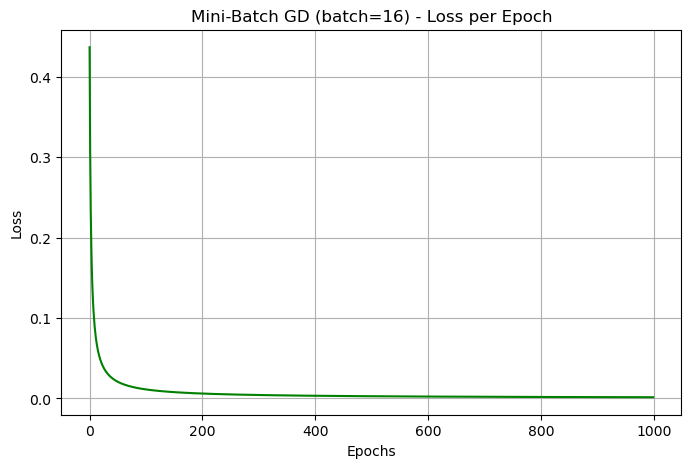

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(mb16_losses, color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Mini-Batch GD (batch=16) - Loss per Epoch')
plt.grid(True)
plt.show()

In [53]:
# Mini-Batch GD (batch=32) 
w = np.zeros(X_tr.shape[1])
b = 0.0
mb32_losses = []

start = time.time()
for _ in range(1000):
    idx = np.random.permutation(len(X_tr))
    X_s, y_s = X_tr[idx], y_tr[idx]
    for i in range(0, len(X_tr), 32):
        xi, yi = X_s[i:i+32], y_s[i:i+32]
        y_pred = sigmoid(xi @ w + b)
        dw = (xi.T @ (y_pred - yi)) / len(yi)
        db = np.mean(y_pred - yi)
        w -= 0.1 * dw
        b -= 0.1 * db
    full_pred = sigmoid(X_tr @ w + b)
    mb32_losses.append(compute_loss(y_tr, full_pred))
mb32_time = time.time() - start
mb32_acc = compute_accuracy(X_te, y_te, w, b)

print("Mini-Batch GD (batch=32) Results:")
print(f"  Training Time : {mb32_time:.4f} seconds")
print(f"  Final Loss    : {mb32_losses[-1]:.4f}")
print(f"  Accuracy      : {mb32_acc:.4f}")

Mini-Batch GD (batch=32) Results:
  Training Time : 0.0640 seconds
  Final Loss    : 0.0023
  Accuracy      : 1.0000


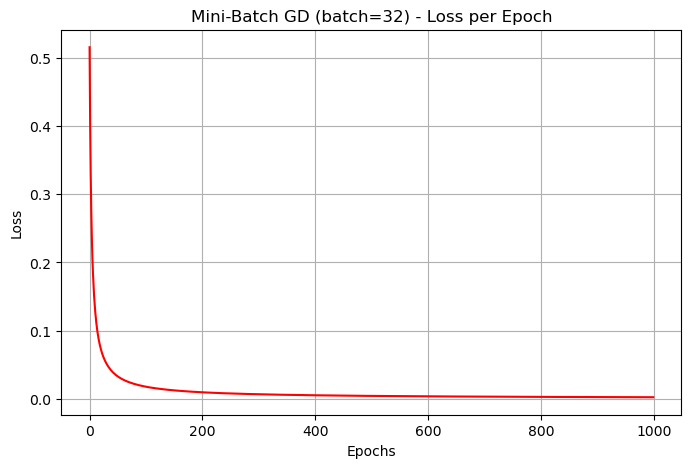

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(mb32_losses, color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Mini-Batch GD (batch=32) - Loss per Epoch')
plt.grid(True)
plt.show()

In [55]:
# Mini-Batch GD (batch=64)
w = np.zeros(X_tr.shape[1])
b = 0.0
mb64_losses = []

start = time.time()
for _ in range(1000):
    idx = np.random.permutation(len(X_tr))
    X_s, y_s = X_tr[idx], y_tr[idx]
    for i in range(0, len(X_tr), 64):
        xi, yi = X_s[i:i+64], y_s[i:i+64]
        y_pred = sigmoid(xi @ w + b)
        dw = (xi.T @ (y_pred - yi)) / len(yi)
        db = np.mean(y_pred - yi)
        w -= 0.1 * dw
        b -= 0.1 * db
    full_pred = sigmoid(X_tr @ w + b)
    mb64_losses.append(compute_loss(y_tr, full_pred))
mb64_time = time.time() - start
mb64_acc = compute_accuracy(X_te, y_te, w, b)

print("Mini-Batch GD (batch=64) Results:")
print(f"  Training Time : {mb64_time:.4f} seconds")
print(f"  Final Loss    : {mb64_losses[-1]:.4f}")
print(f"  Accuracy      : {mb64_acc:.4f}")

Mini-Batch GD (batch=64) Results:
  Training Time : 0.0422 seconds
  Final Loss    : 0.0033
  Accuracy      : 1.0000


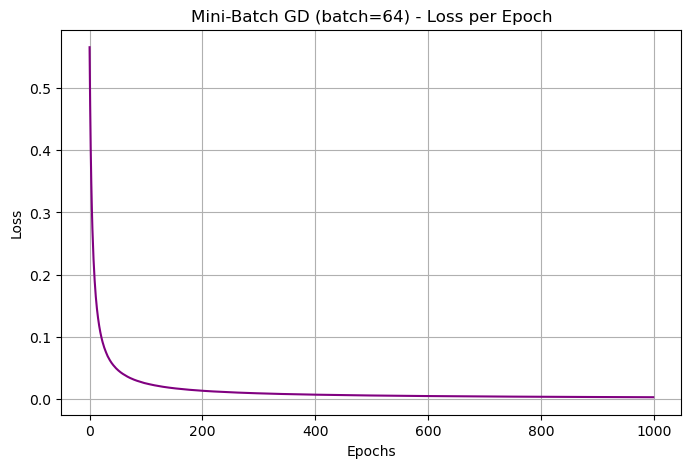

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(mb64_losses, color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Mini-Batch GD (batch=64) - Loss per Epoch')
plt.grid(True)
plt.show()

In [57]:
# SGD with Momentum
w = np.zeros(X_tr.shape[1])
b = 0.0
vw, vb = np.zeros_like(w), 0.0
mom_losses = []

start = time.time()
for _ in range(1000):
    y_pred = sigmoid(X_tr @ w + b)
    dw = (X_tr.T @ (y_pred - y_tr)) / len(y_tr)
    db = np.mean(y_pred - y_tr)
    vw = 0.9 * vw + (1 - 0.9) * dw
    vb = 0.9 * vb + (1 - 0.9) * db
    w -= 0.1 * vw
    b -= 0.1 * vb
    mom_losses.append(compute_loss(y_tr, sigmoid(X_tr @ w + b)))
mom_time = time.time() - start
mom_acc = compute_accuracy(X_te, y_te, w, b)

print("SGD with Momentum Results:")
print(f"  Training Time : {mom_time:.4f} seconds")
print(f"  Final Loss    : {mom_losses[-1]:.4f}")
print(f"  Accuracy      : {mom_acc:.4f}")

SGD with Momentum Results:
  Training Time : 0.0298 seconds
  Final Loss    : 0.0058
  Accuracy      : 1.0000


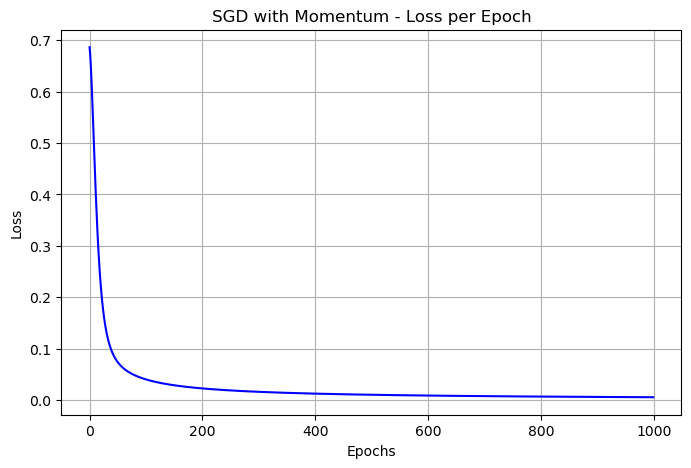

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(mom_losses, color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('SGD with Momentum - Loss per Epoch')
plt.grid(True)
plt.show()

In [59]:
# RMSProp
w = np.zeros(X_tr.shape[1])
b = 0.0
sw, sb = np.zeros_like(w), 0.0
rms_losses = []

start = time.time()
for _ in range(1000):
    y_pred = sigmoid(X_tr @ w + b)
    dw = (X_tr.T @ (y_pred - y_tr)) / len(y_tr)
    db = np.mean(y_pred - y_tr)
    sw = 0.9 * sw + (1 - 0.9) * dw**2
    sb = 0.9 * sb + (1 - 0.9) * db**2
    w -= 0.01 * dw / (np.sqrt(sw) + 1e-8)
    b -= 0.01 * db / (np.sqrt(sb) + 1e-8)
    rms_losses.append(compute_loss(y_tr, sigmoid(X_tr @ w + b)))
rms_time = time.time() - start
rms_acc = compute_accuracy(X_te, y_te, w, b)

print("RMSProp Results:")
print(f"  Training Time : {rms_time:.4f} seconds")
print(f"  Final Loss    : {rms_losses[-1]:.4f}")
print(f"  Accuracy      : {rms_acc:.4f}")

RMSProp Results:
  Training Time : 0.0308 seconds
  Final Loss    : 0.0000
  Accuracy      : 1.0000


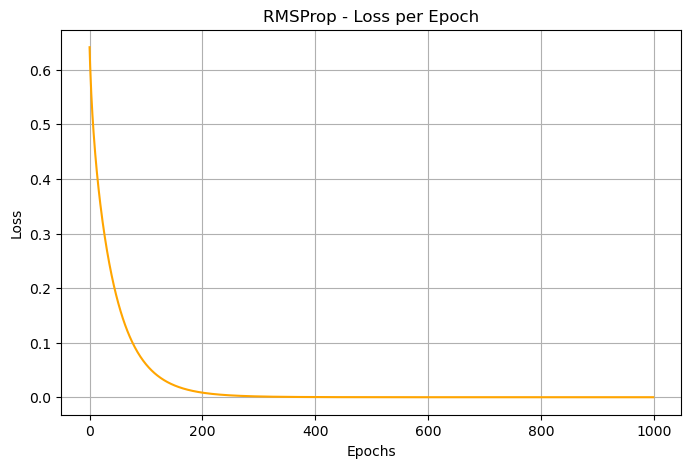

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(rms_losses, color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('RMSProp - Loss per Epoch')
plt.grid(True)
plt.show()

In [61]:
# Adam
w = np.zeros(X_tr.shape[1])
b = 0.0
mw, vw = np.zeros_like(w), np.zeros_like(w)
mb_val, vb = 0.0, 0.0
adam_losses = []

start = time.time()
for t in range(1, 1001):
    y_pred = sigmoid(X_tr @ w + b)
    dw = (X_tr.T @ (y_pred - y_tr)) / len(y_tr)
    db = np.mean(y_pred - y_tr)
    mw = 0.9 * mw + (1 - 0.9) * dw
    mb_val = 0.9 * mb_val + (1 - 0.9) * db
    vw = 0.999 * vw + (1 - 0.999) * dw**2
    vb = 0.999 * vb + (1 - 0.999) * db**2
    mw_hat = mw / (1 - 0.9**t)
    mb_hat = mb_val / (1 - 0.9**t)
    vw_hat = vw / (1 - 0.999**t)
    vb_hat = vb / (1 - 0.999**t)
    w -= 0.01 * mw_hat / (np.sqrt(vw_hat) + 1e-8)
    b -= 0.01 * mb_hat / (np.sqrt(vb_hat) + 1e-8)
    adam_losses.append(compute_loss(y_tr, sigmoid(X_tr @ w + b)))
adam_time = time.time() - start
adam_acc = compute_accuracy(X_te, y_te, w, b)

print("Adam Results:")
print(f"  Training Time : {adam_time:.4f} seconds")
print(f"  Final Loss    : {adam_losses[-1]:.4f}")
print(f"  Accuracy      : {adam_acc:.4f}")

Adam Results:
  Training Time : 0.0395 seconds
  Final Loss    : 0.0056
  Accuracy      : 1.0000


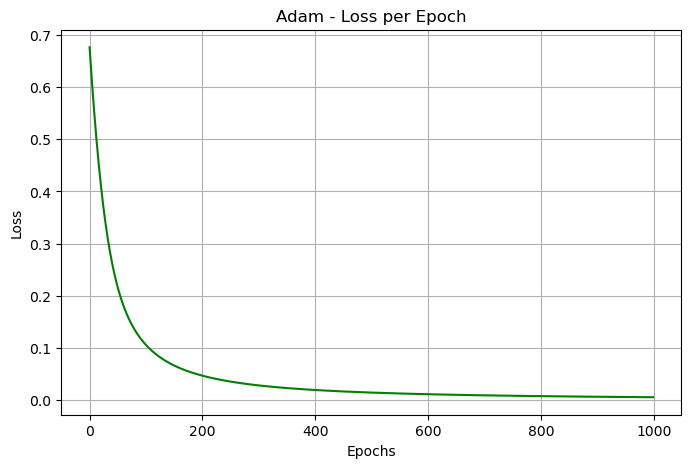

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(adam_losses, color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Adam - Loss per Epoch')
plt.grid(True)
plt.show()

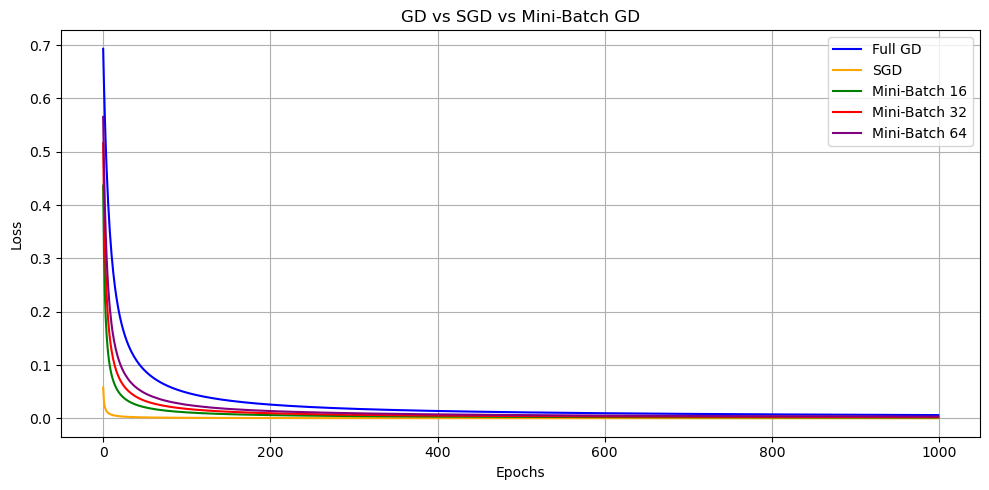

In [63]:
epochs = range(1000)

plt.figure(figsize=(10, 5))
plt.plot(epochs, gd_losses,   label='Full GD',       color='blue')
plt.plot(epochs, sgd_losses,  label='SGD',            color='orange')
plt.plot(epochs, mb16_losses, label='Mini-Batch 16',  color='green')
plt.plot(epochs, mb32_losses, label='Mini-Batch 32',  color='red')
plt.plot(epochs, mb64_losses, label='Mini-Batch 64',  color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('GD vs SGD vs Mini-Batch GD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

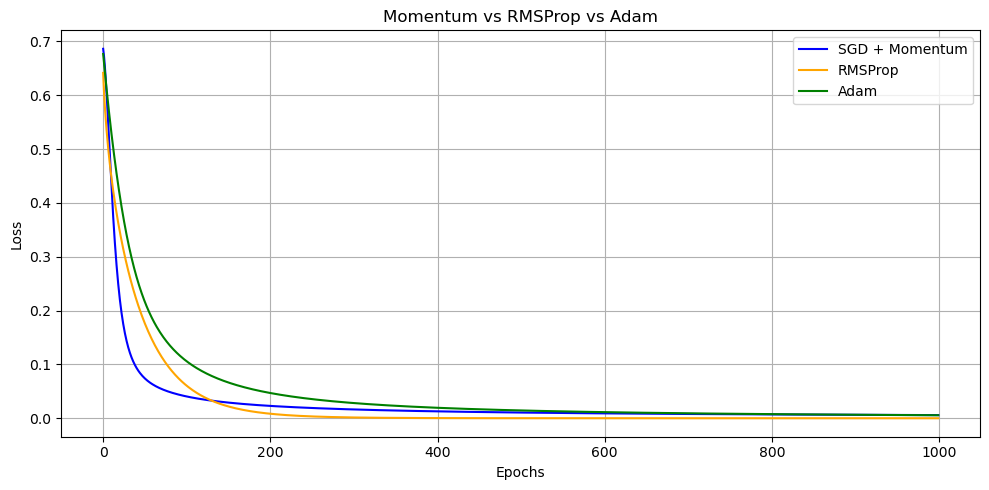

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, mom_losses,  label='SGD + Momentum', color='blue')
plt.plot(epochs, rms_losses,  label='RMSProp',         color='orange')
plt.plot(epochs, adam_losses, label='Adam',             color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Momentum vs RMSProp vs Adam')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
conv_speed  = ["Slow", "Fast", "Medium", "Medium", "Medium", "Fast", "Very Fast", "Very Fast"]
stability   = ["Very High", "Low", "Medium", "Medium", "High", "High", "High", "Very High"]

results = [
    ("Full GD",       gd_time,   gd_losses[-1],   gd_acc),
    ("SGD",           sgd_time,  sgd_losses[-1],  sgd_acc),
    ("Mini-Batch 16", mb16_time, mb16_losses[-1], mb16_acc),
    ("Mini-Batch 32", mb32_time, mb32_losses[-1], mb32_acc),
    ("Mini-Batch 64", mb64_time, mb64_losses[-1], mb64_acc),
    ("Momentum",      mom_time,  mom_losses[-1],  mom_acc),
    ("RMSProp",       rms_time,  rms_losses[-1],  rms_acc),
    ("Adam",          adam_time, adam_losses[-1], adam_acc),
]

print(f"{'Method':<20} {'Conv. Speed':<14} {'Stability':<12} {'Time (s)':<12} {'Final Loss':<14} {'Accuracy':<10}")
print("-" * 82)
for i, (name, t, loss, acc) in enumerate(results):
    print(f"{name:<20} {conv_speed[i]:<14} {stability[i]:<12} {t:<12.4f} {loss:<14.4f} {acc:<10.4f}")

Method               Conv. Speed    Stability    Time (s)     Final Loss     Accuracy  
----------------------------------------------------------------------------------
Full GD              Slow           Very High    0.0250       0.0060         1.0000    
SGD                  Fast           Low          0.6430       0.0001         1.0000    
Mini-Batch 16        Medium         Medium       0.0775       0.0015         1.0000    
Mini-Batch 32        Medium         Medium       0.0640       0.0023         1.0000    
Mini-Batch 64        Medium         High         0.0422       0.0033         1.0000    
Momentum             Fast           High         0.0298       0.0058         1.0000    
RMSProp              Very Fast      High         0.0308       0.0000         1.0000    
Adam                 Very Fast      Very High    0.0395       0.0056         1.0000    
